In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [21]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(16 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # 28 → 14
        x = self.pool(self.relu(self.conv2(x)))   # 14 → 7

        x = x.view(-1, 16 * 7 * 7)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [77]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 11181642


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [23]:
def evaluate(model, loader):
    model.eval()

    total = 0
    correct = 0
    loss_total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    loss_avg = loss_total / len(loader)

    return loss_avg, acc

In [24]:
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    val_loss, val_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Epoch [1/10]
Train Loss: 0.2661, Train Acc: 92.24%
Val Loss: 0.0941, Val Acc: 96.99%
Epoch [2/10]
Train Loss: 0.0776, Train Acc: 97.65%
Val Loss: 0.0607, Val Acc: 98.09%
Epoch [3/10]
Train Loss: 0.0568, Train Acc: 98.27%
Val Loss: 0.0494, Val Acc: 98.36%
Epoch [4/10]
Train Loss: 0.0467, Train Acc: 98.57%
Val Loss: 0.0439, Val Acc: 98.45%
Epoch [5/10]
Train Loss: 0.0397, Train Acc: 98.74%
Val Loss: 0.0416, Val Acc: 98.65%
Epoch [6/10]
Train Loss: 0.0342, Train Acc: 98.94%
Val Loss: 0.0358, Val Acc: 98.83%
Epoch [7/10]
Train Loss: 0.0288, Train Acc: 99.09%
Val Loss: 0.0413, Val Acc: 98.77%
Epoch [8/10]
Train Loss: 0.0245, Train Acc: 99.23%
Val Loss: 0.0367, Val Acc: 98.71%
Epoch [9/10]
Train Loss: 0.0213, Train Acc: 99.34%
Val Loss: 0.0433, Val Acc: 98.60%
Epoch [10/10]
Train Loss: 0.0180, Train Acc: 99.43%
Val Loss: 0.0441, Val Acc: 98.63%


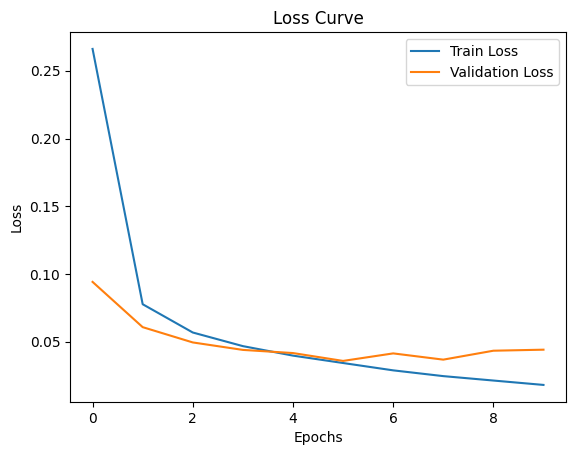

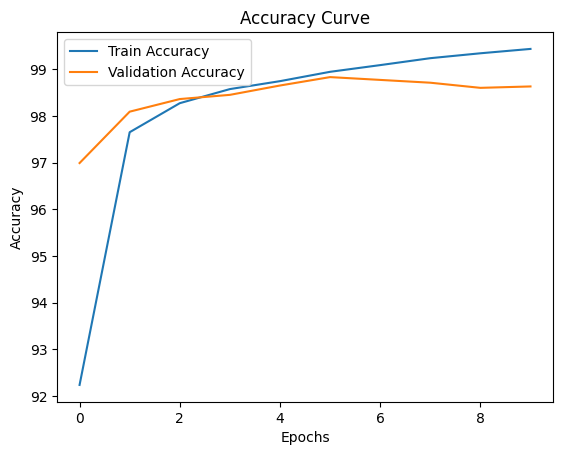

In [75]:
import matplotlib.pyplot as plt

# Loss plot
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

# Accuracy plot
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

### Q1.3: Why does performance drop on the unbiased dataset?

The model learns a strong corelation between color and label in the biased training data. since color is an easier feature to learn than shape, the optimizer minimizes the loss by relying heavily on color information. As a result the modle does not learn robust shape-based features. When evaluated on the unbiased dataset where this correlation is removed, the models performence drops significantly because its learned representation is not generalizable.

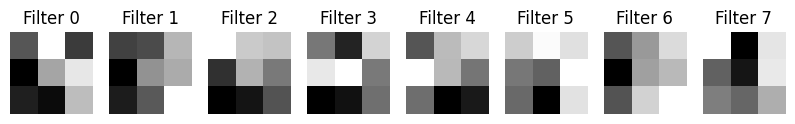

In [25]:
import matplotlib.pyplot as plt

filters = model.conv1.weight.data.cpu()

filters = (filters - filters.min()) / (filters.max() - filters.min())

# Plot
fig, axes = plt.subplots(1, filters.shape[0], figsize=(10, 3))

for i in range(filters.shape[0]):
    axes[i].imshow(filters[i][0], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Filter {i}')

plt.show()

### Q1.2: Interpretation of First Convolutional Layer Filters

The filters in the first convolutional layer capture basic lowlevel feature such as edges and simple textures. Some filters respond strongly to intensity changes in spesific directions (horizontal, vertical, or diagonal), indicating edge detection.These filters act as feature extractors that identify simple patterns like strokes and contours which are later combined by deeper layers to recognize more complex digit structues.

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:


train_data = torch.load("/content/train_biased.pt")
test_biased = torch.load("/content/test_biased.pt")
test_unbiased = torch.load("/content/test_unbiased.pt")

print(len(train_data))

In [29]:
images, labels = train_data

print(type(images), type(labels))
print(images.shape)
print(labels.shape)

<class 'torch.Tensor'> <class 'torch.Tensor'>
torch.Size([60000, 3, 28, 28])
torch.Size([60000])


In [30]:
from torch.utils.data import TensorDataset, DataLoader

train_images, train_labels = train_data
test_biased_images, test_biased_labels = test_biased
test_unbiased_images, test_unbiased_labels = test_unbiased

train_dataset = TensorDataset(train_images, train_labels)
test_biased_dataset = TensorDataset(test_biased_images, test_biased_labels)
test_unbiased_dataset = TensorDataset(test_unbiased_images, test_unbiased_labels)

train_loader_cm = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_biased_loader = DataLoader(test_biased_dataset, batch_size=64, shuffle=False)
test_unbiased_loader = DataLoader(test_unbiased_dataset, batch_size=64, shuffle=False)

In [31]:
class SimpleCNN_RGB(nn.Module):
    def __init__(self):
        super(SimpleCNN_RGB, self).__init__()

        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(16 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 16 * 7 * 7)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [32]:
model_cm = SimpleCNN_RGB().to(device)
optimizer_cm = optim.Adam(model_cm.parameters(), lr=0.001)

In [33]:
for epoch in range(10):
    model_cm.train()

    correct = 0
    total = 0

    for images, labels in train_loader_cm:
        images, labels = images.to(device), labels.to(device)

        optimizer_cm.zero_grad()
        outputs = model_cm(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_cm.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}, Accuracy: {100*correct/total:.2f}%")

Epoch 1, Accuracy: 93.48%
Epoch 2, Accuracy: 97.77%
Epoch 3, Accuracy: 98.57%
Epoch 4, Accuracy: 98.88%
Epoch 5, Accuracy: 99.05%
Epoch 6, Accuracy: 99.20%
Epoch 7, Accuracy: 99.33%
Epoch 8, Accuracy: 99.41%
Epoch 9, Accuracy: 99.48%
Epoch 10, Accuracy: 99.53%


In [34]:
biased_loss, biased_acc = evaluate(model_cm, test_biased_loader)
unbiased_loss, unbiased_acc = evaluate(model_cm, test_unbiased_loader)

print("Biased Test Accuracy:", biased_acc)
print("Unbiased Test Accuracy:", unbiased_acc)

Biased Test Accuracy: 99.28
Unbiased Test Accuracy: 91.52


### Q1.3: Performance Drop on Unbiased Dataset

The model acheives very high accuracy on the biased test set, but its performance drops significantly on the unbiased test set.Conceptualy the model learns a strong corelation between color and label in the biased training data. Since color is an easier and more consistent feature than shape, the optimizer minimizes the loss by relying on color rather than learning the actual digit structure. Mathematicaly during trainig features that provide the strongest gradient signals (i.e., reduce loss quickly) are prioritized. Since color is highly predictive in the biased dataset, it dominates the learned representation. When this correlation is removed in the unbiased test set, the model fails to generalize, leading to a drop in accuracy.

### Q1.4: Strategies to Encourage Shape-Based Learning

To force the model to focus on shape instead of color, the following strategies can be used:,
- Convert images to grayscale to remove color information entirely.
- Apply data augmenttation (e.g., random color jittering) to break the correlation between color and label.
- Use a balanced dataset where color is not predictive of the class.
- Introduce regularisation techniques such as dropout to reduce over-reliance on specific features.
- Train with adversarial or domain randomized data to improve robustness.


**Task 2**

In [35]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [36]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [37]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.STL10(
    root='./data',
    split='train',
    download=True,   # ✅ change this
    transform=transform
)

test_dataset = datasets.STL10(
    root='./data',
    split='test',
    download=True,   # ✅ change this
    transform=transform
)

100%|██████████| 2.64G/2.64G [01:54<00:00, 23.0MB/s]


In [38]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [39]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [40]:
import torchvision.models as models

model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 113MB/s]


In [41]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [42]:
for param in model.parameters():
    param.requires_grad = False

In [43]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer3.0.conv1.weight False
layer3.0.bn1.weight False
layer3.0.bn1.bias False
layer3.0.conv2.weight False
layer3.0.bn2.weight False
layer3.0.bn2.bias False
layer3.0.downsample.0.weight False
layer3.0.downsample.1.weight Fa

In [44]:
import torch.nn as nn

model.fc = nn.Linear(model.fc.in_features, 10)

In [45]:
print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


In [46]:
for param in model.fc.parameters():
    param.requires_grad = True

In [47]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [48]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [49]:
model.fc.parameters()

<generator object Module.parameters at 0x7f554c3c4580>

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [52]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total = 0
    correct = 0
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Accuracy={acc:.2f}%")

Epoch 1: Loss=44.3578, Accuracy=92.52%
Epoch 2: Loss=35.9677, Accuracy=93.60%
Epoch 3: Loss=31.3147, Accuracy=94.30%
Epoch 4: Loss=27.9817, Accuracy=94.64%
Epoch 5: Loss=26.1387, Accuracy=94.68%


In [53]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [54]:
test_acc = evaluate(model, test_loader)
print("Test Accuracy:", test_acc)

Test Accuracy: 94.6875


Part B

In [55]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 43.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=7d9053a03b8967562f8d8573cbdc2e4e96fed4c96eec2a5188373396afd2cfaf
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [63]:

model.eval()

for param in model.parameters():
    param.requires_grad = True

In [64]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

In [65]:
target_layer = model.layer4[-1]

In [66]:
images, labels = next(iter(test_loader))

image = images[0].unsqueeze(0).to(device)

In [68]:
cam = GradCAM(model=model, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=image)[0]

img = images[0].permute(1, 2, 0).numpy()
img = (img - img.min()) / (img.max() - img.min())

visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)


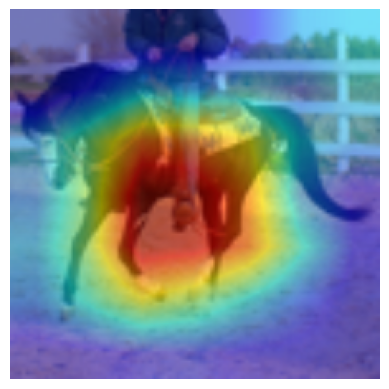

In [69]:
import matplotlib.pyplot as plt
plt.imshow(visualization)
plt.axis('off')
plt.show()

In [71]:
correct_images = []
wrong_images = []

model.eval()

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(len(images)):
        img = images[i].unsqueeze(0)
        label = labels[i].item()
        pred = preds[i].item()

        if pred == label and len(correct_images) < 2:
            correct_images.append((img, label, pred))

        elif pred != label and len(wrong_images) < 2:
            wrong_images.append((img, label, pred))

        if len(correct_images) == 2 and len(wrong_images) == 2:
            break

    if len(correct_images) == 2 and len(wrong_images) == 2:
        break

In [72]:
def show_gradcam(img_tensor, label, pred):
    cam = GradCAM(model=model, target_layers=[target_layer])

    grayscale_cam = cam(input_tensor=img_tensor)[0]

    img = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

    plt.imshow(visualization)
    plt.title(f"True: {label}, Pred: {pred}")
    plt.axis('off')
    plt.show()

Correct Predictions:


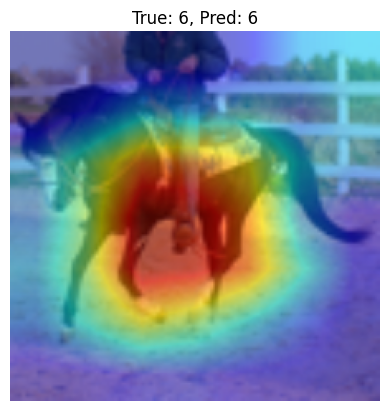

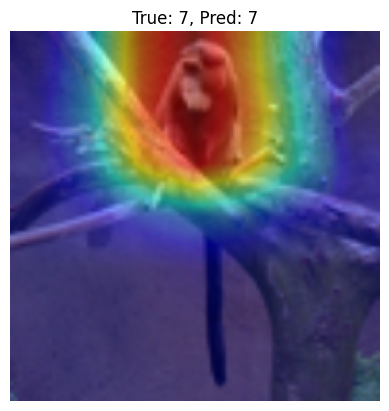

Incorrect Predictions:


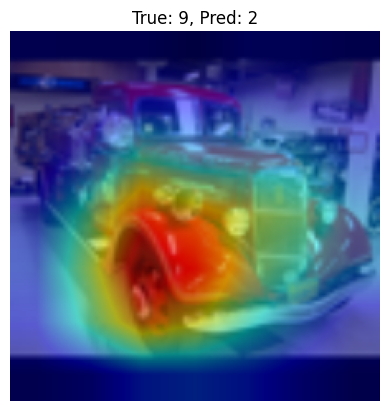

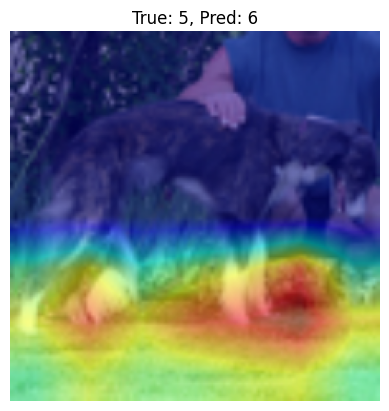

In [73]:
print("Correct Predictions:")
for img, label, pred in correct_images:
    show_gradcam(img, label, pred)

print("Incorrect Predictions:")
for img, label, pred in wrong_images:
    show_gradcam(img, label, pred)

### Q2.1: Why do we freeze early layers in transfer learning?

Early layers in convollutional networks learn general features such as edges textures and simple patterns that are useful across many tasks.  Freezzing these layers reduces computationall cost and prevents overfiting especially when the new dataset is small. The later layers are then fine tuned to learn task-specific features relevant to the new dataset.

### Q2.2: Analysis of GradCAM for correct predictions

For correct predections, the GradCAM heatmaps show that the modle focuses on the main object in the image . This indicates that the model is using relevant and meaningful features for classiffication which leads to correct predictions.

### Q2.3: Analysis of GradCAM for incorrect predictions

For incorrect predections the heatmaps often highlight irelevant regions such as the background or less informative parts of the image. This suggests that the model is relying on misleading or incomplete features which leads to incorect classifications.